In [46]:
import os
import warnings
import logging
from collections import defaultdict
from typing import Tuple, List, Dict, Optional

# === Numerical and Data Tools ===
import numpy as np
import numpy.ma as ma
import pandas as pd
import xarray as xr
import xcdat as xc
import xskillscore as xs

from datetime import datetime

# === Plotting ===
import matplotlib.pyplot as plt
from matplotlib.pylab import rcParams
from matplotlib.patches import Polygon
from matplotlib import ticker
from matplotlib.ticker import FuncFormatter
from matplotlib.cm import get_cmap

# === Mapping and Projections ===
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.mpl.ticker as cticker


from DartObsDiagUtil import (
    DartObsDiagReader
)

# === Suppress warnings globally ===
warnings.filterwarnings("ignore")

In [47]:
def extract_exp_info(exp_name: str = None) -> dict:
    """
    Returns the full DART diagnostic configuration including global settings
    and experiment-specific metadata.

    Parameters
    ----------
    exp_name : str, optional
        Specific experiment to extract (e.g., 'DARTEN10'). If None, return all experiments.

    Returns
    -------
    dict
        Combined configuration dictionary with 'global' and 'experiments' keys.
    """
    config = {
        'global': {
            'case_name': 'JAN2011',
            'resolution': "F20TR_ne30pg2_r05_IcoswISC30E3r5",
            'machine': "compy",
            'diag_key': "obs_diag_output",
            'frequency': "6hourly",
            'region': 'Northern Hemisphere',
            'path_template': "/compyfs/zhan391/v3_dart_cda_scratch/%(RUNNAME)/archive/%(CASENAME)/dart_diagnostics/%(DIAG)",
            'file_template': "%(RUNNAME).dart.e.eam_%(KEY).%(TIME).nc"
        },
        'experiments': {
            'CAM80-S0': {
                'run': 'f.e21.FHIST_BGC.f09_025.CAM6assim.011',
                'key': 'dart_en80',
                'alias': 'CAM6EN80',
                'diag1': 'obs_seq',
                'diag2': 'obs_diag',
                'diag3': 'obs_common',
                'diag4': 'closest_member',
                'diag5': 'cam6_common',
                'period': '2011120100-2012010100',
            },
            'CAM80-S1': {
                'run': 'f.e22.FHIST_BGC.f09_025.CAM6assim.011',
                'key': 'dart_en80',
                'alias': 'CAM6EN80S1',
                'diag1': 'obs_seq',
                'diag2': 'obs_diag',
                'diag3': 'obs_common',
                'diag4': 'closest_member',
                'diag5': 'cam6_common',
                'period': '2012050100-2012060100',
            },
            'CTRL10-S0': {
                'run': 'CTRLEN10_F20TR_ne30pg2_r05_IcoswISC30E3r5_compy',
                'key': 'dart_en10',
                'alias': 'CTRLEN10',
                'diag1': 'obs_seq',
                'diag2': 'obs_diag',
                'diag3': 'obs_common',
                'diag4': 'closest_member',
                'diag5': 'cam6_common',
                'period': '2011120100-2012010100',
            },
            'DART10-S0': {
                'run': 'DARTEN10_F20TR_ne30pg2_r05_IcoswISC30E3r5_compy',
                'key': 'dart_en10',
                'alias': 'DARTEN10',
                'diag1': 'obs_seq',
                'diag2': 'obs_diag',
                'diag3': 'obs_common',
                'diag4': 'closest_member',
                'diag5': 'cam6_common',
                'period': '2011120100-2012010100',
            },
            'DART20-S0': {
                'run': 'DARTEN20_F20TR_ne30pg2_r05_IcoswISC30E3r5_compy',
                'key': 'dart_en20',
                'alias': 'DARTEN20',
                'diag1': 'obs_seq',
                'diag2': 'obs_diag',
                'diag3': 'obs_common',
                'diag4': 'closest_member',
                'diag5': 'cam6_common',
                'period': '2011120100-2012010100',
            },
            'DART40INF0p6-S0': {
                'run': 'DARTEN40_INF0p6_F20TR_ne30pg2_r05_IcoswISC30E3r5_compy',
                'key': 'dart_en40',
                'alias': 'DARTEN40',
                'diag1': 'obs_seq',
                'diag2': 'obs_diag',
                'diag3': 'obs_common',
                'diag4': 'closest_member',
                'diag5': 'cam6_common',
                'period': '2011120100-2012010100',
            },
            'DART40-S0': {
                'run': 'DARTEN40_F20TR_ne30pg2_r05_IcoswISC30E3r5_compy',
                'key': 'dart_en40',
                'alias': 'DARTEN40',
                'diag1': 'obs_seq',
                'diag2': 'obs_diag',
                'diag3': 'obs_common',
                'diag4': 'closest_member',
                'diag5': 'cam6_common',
                'period': '2011120100-2012010100',
            },
            'DART40-S1': {
                'run': 'DARTEN40S1_F20TR_ne30pg2_r05_IcoswISC30E3r5_compy',
                'key': 'dart_en40',
                'alias': 'DARTEN40S1',
                'diag1': 'obs_seq',
                'diag2': 'obs_diag',
                'diag3': 'obs_common',
                'diag4': 'closest_member',
                'diag5': 'cam6_common',
                'period': '2012050100-2012060100',
            }
        }
    }
    
    # If a specific experiment is requested, filter
    if exp_name:
        exps = config['experiments']
        config['experiments'] = {exp_name: exps[exp_name]} if exp_name in exps else {}

    return config

In [128]:
class ObsDiagPlotter:
    def __init__(
        self, var, var_dict, data_dict, fig_path,
        plevstr, region = None, regnam=None
    ):
        self.var = var
        self.var_dict = var_dict or {}
        self.data_dict = data_dict or {}
        self.fig_path = fig_path
        self.plevstr = plevstr or []
        self.region = region
        self.regnam = regnam
        self._prepare_common()

    def _prepare_common(self):
        self.cmap = {
            'blue': '#377eb8', 'orange': '#ff7f00', 'green': '#4daf4a',
            'pink': '#f781bf', 'brown': '#a65628', 'purple': '#984ea3',
            'gray': '#999999', 'red': '#e41a1c', 'yellow': '#dede00'
        }

    def _set_axes_limits(self, ax, xlim=None, ylim=None, yticks=None, xticks=None):
        if xlim is not None: ax.set_xlim(*xlim)
        if ylim is not None: ax.set_ylim(*ylim)
        if yticks is not None: ax.set_yticks(yticks)
        if xticks is not None: ax.set_xticks(xticks)

    # NEW: robust getter for inner var-config
    def _varcfg(self):
        """Return inner var-config whether var_dict is an inner dict or a single-entry wrapper."""
        vd = self.var_dict
        if isinstance(vd, dict) and 'y1aix' in vd:
            return vd
        if isinstance(vd, dict) and len(vd) == 1:
            return next(iter(vd.values()))
        raise ValueError(
            "var_dict not recognized. Pass inner dict with keys like 'y1aix'/'y2aix', "
            "or a single-entry wrapper {var_key: inner}."
        )

    def check_flat_lev_consistency(self, lev_dict):
        ref_var = next(iter(lev_dict))
        reference = lev_dict[ref_var]
        for var, lev in lev_dict.items():
            if lev != reference:
                raise ValueError(
                    f"Inconsistent pressure level list for variable '{var}'.\n"
                    f"Expected: {reference}\nFound:    {lev}"
                )
        print("All level lists are consistent across variables.")
        return reference
    
    def build_ts_var_dict(
        self, var_key: str = None, name: str = None,
        y1axis: list = None, y2axis: list = None
    ) -> dict:
        var_key = var_key or 'RADIOSONDE_U'
        name = name or 'RADIOSONDE_U_WIND_COMPONENT'
        entry = {
            'name': name,
            'lev_type': 'pressure',
            'CopySpread': 'totalspread',
            'CopyRMSE': 'rmse',
            'CopyNposs': 'Nposs',
            'CopyNused': 'Nused',
            'type1': 'guess',
            'type2': 'VPguess',
            'type3': 'guess_RankHist',
            'y1aix': y1axis if y1axis is not None else [0, 10],
            'y2aix': [0, 100],
            'y1aix0': y2axis if y2axis is not None else [0, 10],
            'y2aix0': [0, 100],
        }
        return {var_key: entry}
    
    def compute_experiment_means(self, data_dict, diagnostic_keys_to_average):
        sample_var_data = next(iter(data_dict.values()))
        experiments = list(sample_var_data.keys())
        all_diagnostic_keys = next(iter(sample_var_data.values())).keys()
        mean_dict = {}
        for exp in experiments:
            mean_dict[exp] = {}
            for key in all_diagnostic_keys:
                if key in diagnostic_keys_to_average:
                    valid_data = []
                    for var in data_dict:
                        entry = data_dict[var].get(exp, {}).get(key, None)
                        if (isinstance(entry, np.ndarray)
                            and entry.size > 0
                            and not np.all(np.isnan(entry))):
                            valid_data.append(entry)
                    if valid_data:
                        try:
                            stacked = np.stack(valid_data, axis=0)
                            mean_array = np.nanmean(stacked, axis=0)
                        except ValueError:
                            shapes = [arr.shape for arr in valid_data]
                            print(f"[WARN] Shape mismatch for '{key}' in '{exp}': {shapes}. Skipping mean.")
                            mean_array = None
                    else:
                        mean_array = None
                    mean_dict[exp][key] = mean_array
                else:
                    values = [
                        data_dict[var][exp][key]
                        for var in data_dict
                        if exp in data_dict[var] and key in data_dict[var][exp]
                    ]
                    if not values:
                        mean_dict[exp][key] = None
                        continue
                    first_val = values[0]
                    if all(np.array_equal(first_val, v) for v in values):
                        mean_dict[exp][key] = first_val
                    else:
                        raise ValueError(
                            f"Inconsistent values for diagnostic key '{key}' in experiment '{exp}'."
                        )
        return mean_dict
    
    def _auto_ylims(self, values, *, pad_frac=0.25, symmetric=False):
        """
        Compute nice y-limits from a 1D array-like metric.

        Parameters
        ----------
        values : array-like
            Metric values (nan-safe).
        pad_frac : float
            Fractional padding on each side (default 0.10 = 10%).
        symmetric : bool
            If True, make y-limits symmetric around zero.
        """
        import numpy as np

        arr = np.asarray(values, dtype=float)
        arr = arr[np.isfinite(arr)]
        if arr.size == 0:
            return (-1, 1)  # fallback

        vmin, vmax = arr.min(), arr.max()

        # If all values identical → pad around that value
        if np.isclose(vmin, vmax):
            delta = abs(vmin) * pad_frac if vmin != 0 else 1.0
            return (vmin - delta, vmax + delta)

        if symmetric:
            bound = max(abs(vmin), abs(vmax))
            pad = bound * pad_frac
            return (-bound - pad, bound + pad)

        # Regular: padded min/max
        pad = (vmax - vmin) * pad_frac
        return (vmin - pad, vmax + pad)

    def plot_metric_by_experiment(
            self,
            plev_subset,
            metrics,
            metric_dict,
            xmin,
            xmax,
            xunit,
            fontz,
            dpi,
            panel_width,
            panel_height,
            show,
            save,
            fig_idx=0,
            shared_legend=True, 
        ):
        """
        For each metric (rmse, spread), generate one figure.
        Each figure contains one panel per experiment, and
        all pressure levels are plotted inside that panel.
        """

        exp_names = list(self.data_dict.keys())
    
        # Use Tableau colors
        tableau = [
            "#4e79a7","#f28e2b","#e15759","#76b7b2",
            "#59a14f","#edc948","#b07aa1","#ff9da7"
        ]
    
        for metric in metrics:
    
            nrows = len(exp_names)
            fig, axes = plt.subplots(
                nrows=nrows,
                ncols=1,
                figsize=(panel_width, panel_height),
                sharex=True,
            )
            axes = np.atleast_1d(axes)
    
            for i, exp in enumerate(exp_names):
                ax = axes[i]
                d = self.data_dict[exp]
                time = np.asarray(d["time"])
                mask = (time >= xmin) & (time <= xmax)
                time_f = time[mask]
    
                # Reliability band for spread only
                if metric == "spread":
                    low, high = metric_dict["spread"]["reliability_band"]
                    ax.axhspan(
                        low, high, color="grey", alpha=0.4, zorder=0
                    )
                    ax.axhline(1.0, color="k", linestyle="--", lw=1.2, zorder=1)
    
                # Plot all selected levels
                for il, lev in enumerate(plev_subset):
                    color = tableau[il % len(tableau)]
    
                    # compute metric
                    if metric == "spread":
                        spread = np.clip(np.asarray(d["spread"]), 1e-4, None)
                        rmse   = np.clip(np.asarray(d["rmse"]),   1e-4, None)
                        values = spread / rmse
                    else:   # rmse
                        values = np.asarray(d["rmse"])
    
                    if values.ndim != 2:
                        raise ValueError("Metric array must be time × level.")
    
                    vals = values[mask, self.plevstr.index(lev)]
    
                    ax.plot(
                        time_f, vals,
                        label=lev.replace(" ", ""),
                        color=color,
                        lw=2.0,
                        alpha=0.9
                    )
    
                # axis formatting
                cfg = metric_dict[metric]
                ax.set_ylim(cfg["ylim"])
                ax.set_ylabel(cfg["unit"], fontsize=fontz*1.0)
                ax.tick_params(labelsize=fontz * 0.95)
                panel_title = f"({chr(97 + i + fig_idx)}) {exp} ({self.var})"
                ax.set_title(panel_title, fontsize=fontz * 1.01, pad=8, loc="left")
                ax.set_title(
                    cfg['name'],
                    fontsize=fontz * 1.01,
                    pad=8,
                    loc="right",
                )
                
                if i == len(exp_names) - 1:
                    ax.set_xlabel(f"Days since {xunit}", fontsize=fontz*1.0)

                if not shared_legend:
                    ax.legend(fontsize=fontz * 0.95, ncol=2)
                else: 
                    # collect handles & labels
                    handles, labels = ax.get_legend_handles_labels()
                    
            # === shared legend ===
            fig.legend(
                handles, labels,
                loc='lower center',
                ncol=len(labels)//2 + 1,
                fontsize=fontz*0.95,
                frameon=True,
                bbox_to_anchor=(0.5, -0.05)
            )
            
            plt.tight_layout()
            if show:
                plt.show()
            if save:
                fname = os.path.join(
                    self.fig_path,
                    f"fig_metric_{metric}_{self.var}_{self.region}.pdf"
                )
                fig.savefig(fname, dpi=dpi, bbox_inches="tight")
                plt.close(fig)


Found match for variable U_WIND in Conventional: RADIOSONDE_U_WIND_COMPONENT
Reading file: /compyfs/zhan391/v3_dart_cda_scratch/CTRLEN10_F20TR_ne30pg2_r05_IcoswISC30E3r5_compy/archive/dart_en10/dart_diagnostics/obs_diag/CTRLEN10_F20TR_ne30pg2_r05_IcoswISC30E3r5_compy.dart.e.eam_obs_diag_output.2011120100-2012010100.nc
Reading file: /compyfs/zhan391/v3_dart_cda_scratch/DARTEN10_F20TR_ne30pg2_r05_IcoswISC30E3r5_compy/archive/dart_en10/dart_diagnostics/obs_diag/DARTEN10_F20TR_ne30pg2_r05_IcoswISC30E3r5_compy.dart.e.eam_obs_diag_output.2011120100-2012010100.nc
Reading file: /compyfs/zhan391/v3_dart_cda_scratch/DARTEN20_F20TR_ne30pg2_r05_IcoswISC30E3r5_compy/archive/dart_en20/dart_diagnostics/obs_diag/DARTEN20_F20TR_ne30pg2_r05_IcoswISC30E3r5_compy.dart.e.eam_obs_diag_output.2011120100-2012010100.nc
Reading file: /compyfs/zhan391/v3_dart_cda_scratch/DARTEN40_F20TR_ne30pg2_r05_IcoswISC30E3r5_compy/archive/dart_en40/dart_diagnostics/obs_diag/DARTEN40_F20TR_ne30pg2_r05_IcoswISC30E3r5_compy.dar

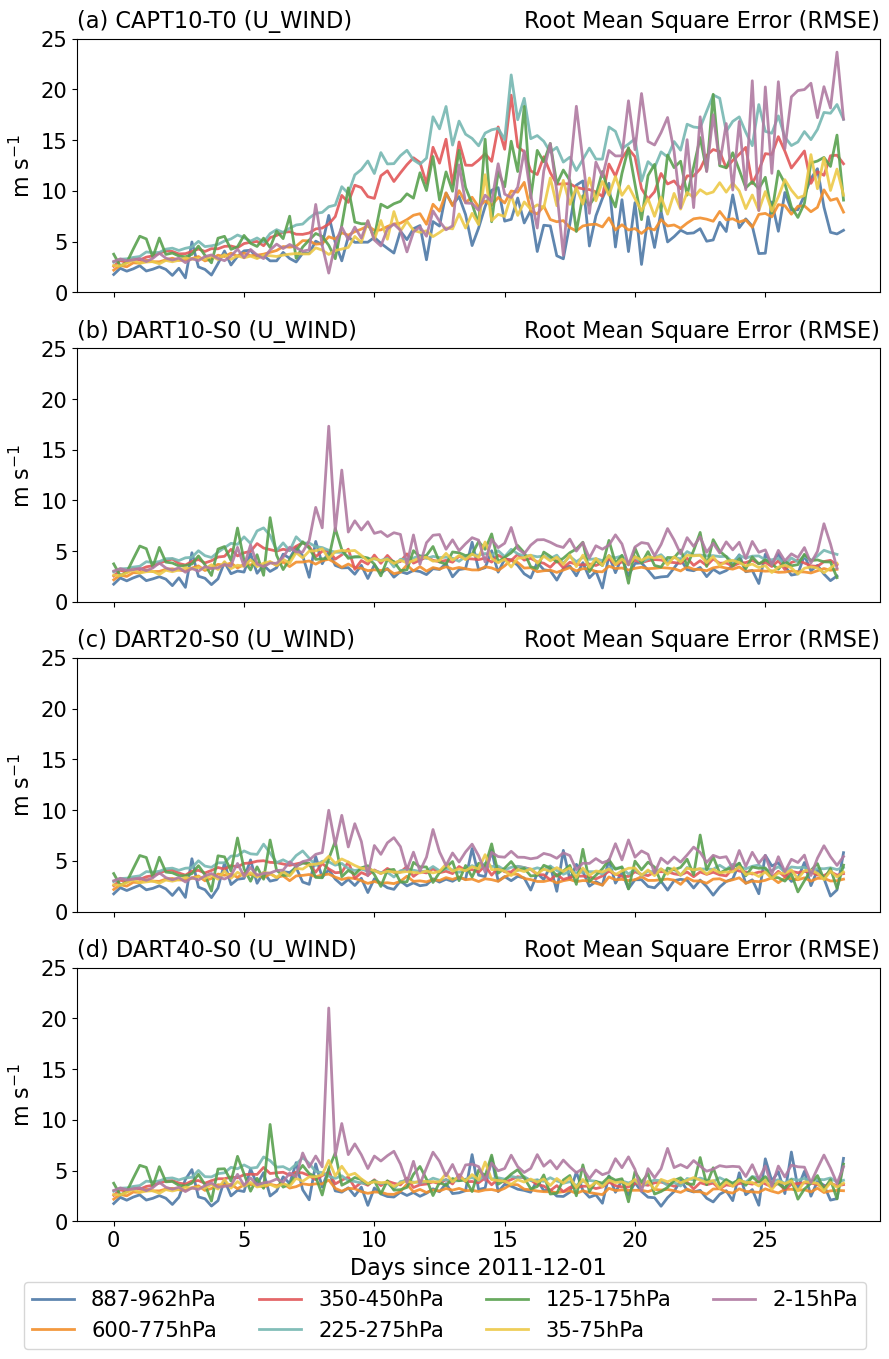

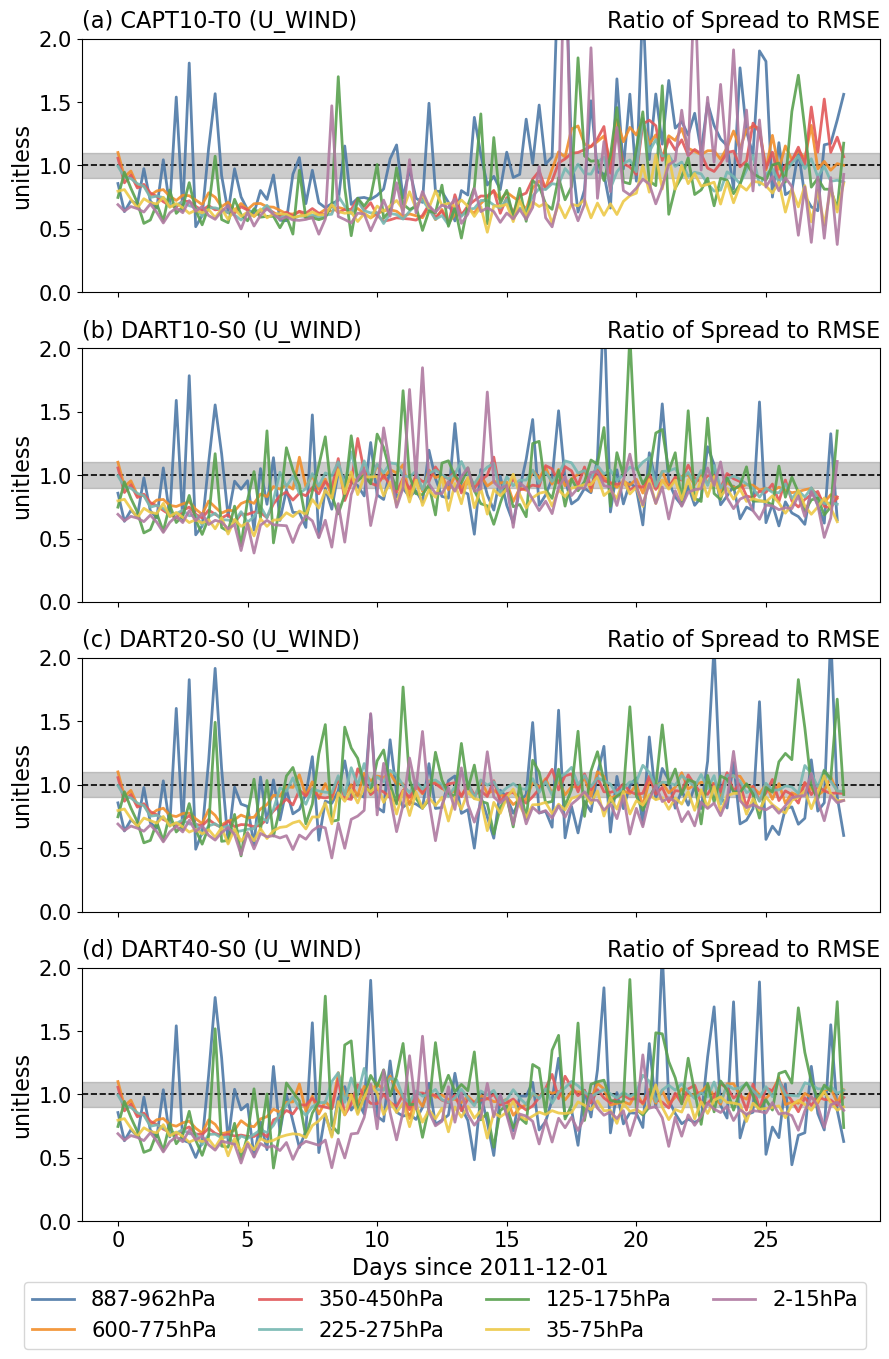

In [132]:
if __name__ == "__main__":
    top_path = "/compyfs/zhan391/v3_dart_cda_scratch"
    out_path = "/compyfs/zhan391/v3_dart_cda_scratch/diag_dart"
    fig_path = "./"
    
    # === Configuration and inputs ===
    exp_info = extract_exp_info()
    exp_cfg  = exp_info["global"]
    exps = ['CTRL10-S0','DART10-S0','DART20-S0','DART40-S0']  # , 'DARTEN40_INF0p6']
    labels = ['CAPTEN10-T0','DART10-S0','DART20-S0','DART40-S0']  # , 'DARTEN40_INF0p6']
    exp_dict = {
        label: exp_info["experiments"][exp_tgt]
        for exp_tgt,label in zip(exps,labels)
    }
    reg_dict = {
        "NH":      "Northern Hemisphere",
        "SH":      "Southern Hemisphere",
        "Tropics": "Tropics",
        "NA":      "North America",
        "Global":  "global",
    }

    varstr   = "U_WIND"
    varunt   = "m s$^{-1}$"
    varlev   = "plevel"
    diag_set = "diag2"
    dtype    = "guess"            # also accepts 'VPguess', 'guess_RankHist' if supported
    tunit    = "2011-12-01"
    
    # Region name
    region   = "NH"
    regnam = reg_dict.get(region, region)

    # Only RMSE and Spread; we won't use rejection anymore
    metric_dict  = {
        "rmse": {
            "name": "Root Mean Square Error (RMSE)",
            "unit": varunt,
            "pad_frac": 0.05,
            "ylim": (0,25)
        },
        "spread": {
            "name": "Ratio of Spread to RMSE",
            "unit": "unitless",
            "pad_frac": 0.25,
            "ylim": (0,2.0),
            "reliability_band": (0.9, 1.1),   # <<< shaded band
        },
    }

    # Metrics to average across variables when building experiment means
    metrics = ["rmse", "spread"]
    
    # Only plot these levels; set to None to use all levels
    #plot_levs = ["887-962 hPa", "775-887 hPa", "450-600 hPa", "225-275 hPa", "75-125 hPa", "15-35 hPa"]
    plot_levs = None #[ "775-887 hPa", "450-600 hPa", "225-275 hPa", "75-125 hPa", "15-35 hPa"]
    plot_levs = None #[ "600-775 hPa", "450-600 hPa", "225-275 hPa", "75-125 hPa", "15-35 hPa"]

    vbound   = ([1, 7], [0, 18])  # (primary y-axis bounds, secondary y-axis bounds)
    xmin     = 0
    xmax     = 28
    xmean    = 15   # currently unused
    show     = True
    save     = True
    panel_width  = 9
    panel_height = 13
    fontz = 16
    dpi   = 600 
    
    # === Initialize diagnostics reader and discover available obs ===
    reader = DartObsDiagReader(exp_cfg)
    all_obs = reader.extract_obs_group()

    # Matches: non-satellite, level substring match, variable substring match (case-insensitive)
    matches = [
        (group, lev, vv)
        for group, levels in all_obs.items()
        if "Satellite" not in group
        for lev, variables in levels.items()
        if varlev.lower() in lev.lower()
        for vv in variables
        if varstr.lower() in vv.lower()
    ]

    if not matches:
        raise RuntimeError(
            f"No matches for var='{varstr}' at level like '{varlev}' "
            f"(excluding Satellite). Check your obs groups."
        )

    # === Gather data for each matching variable name ===
    data_dict = {}
    lev_dict  = {}
    for vgroup, vlev, vname in matches:
        print(f"Found match for variable {varstr} in {vgroup}: {vname}")
        # Build display/axis config for THIS variable name using the reader's helper
        var_cfg = reader.build_ts_var_dict(varstr, name=vname)
        # Extract metrics; pass exp_dict that is already defined
        dat, levs = reader.extract_metrics_data(
            var=varstr,
            var_dict=var_cfg[varstr],
            dtype=dtype,
            regnam=regnam,
            diag_set=diag_set,
            exp_dict=exp_dict,
        )
        data_dict[vname] = dat
        lev_dict[vname]  = levs

    # === Plotting ===
    plotter = ObsDiagPlotter(
        var=None, 
        var_dict=None, 
        data_dict=None, 
        plevstr=None,
        region=region,
        regnam=regnam, 
        fig_path=fig_path
    )
    
    # Ensure pressure levels consistent across matched variables
    lev_str = plotter.check_flat_lev_consistency(lev_dict)
    if not lev_str:
        raise RuntimeError("Pressure levels inconsistent across variables; cannot proceed.")
    
    # Drop 'rejection' from raw data if present, since we no longer use it
    for vname, vdata in data_dict.items():
        for exp_name, exp_data in vdata.items():
            exp_data.pop("rejection", None)

    # Calculate mean of all available observations (rmse, spread, and other consistent keys)
    data_dict_mean = plotter.compute_experiment_means(
        data_dict, diagnostic_keys
    )

    # Build a unified var_dict for the final plot (still reused from your original design)
    var_dict = plotter.build_ts_var_dict(
        varstr, name=varstr, y1axis=vbound[0], y2axis=vbound[1],
    )
    
    # Push state into plotter
    plotter.var = varstr
    plotter.var_dict = var_dict
    plotter.data_dict = data_dict_mean
    plotter.plevstr = lev_str

    # === Generate time series at selected levels: one figure per level, 2 panels (rmse & spread) ===
    if plot_levs is None:
        plot_levs = lev_str[1::2]

    for i, lev in enumerate(plot_levs):
        if lev not in lev_str:
            print(f"[WARN] Requested level '{lev}' not found in lev_str; skipping.")
            continue
            
    fig_idx = 0   # for panel lettering (a,b,c,...)

    plotter.plot_metric_by_experiment(
        plev_subset=plot_levs,
        metrics=metrics,
        metric_dict=metric_dict,
        xmin=xmin,
        xmax=xmax,
        xunit=tunit,
        fontz=fontz,
        dpi=dpi,
        panel_width=panel_width,
        panel_height=panel_height,
        show=show,
        save=save,
    )

Found match for variable Temperature in Conventional: TEMPERATURE
Reading file: /compyfs/zhan391/v3_dart_cda_scratch/CTRLEN10_F20TR_ne30pg2_r05_IcoswISC30E3r5_compy/archive/dart_en10/dart_diagnostics/obs_diag/CTRLEN10_F20TR_ne30pg2_r05_IcoswISC30E3r5_compy.dart.e.eam_obs_diag_output.2011120100-2012010100.nc
Reading file: /compyfs/zhan391/v3_dart_cda_scratch/DARTEN10_F20TR_ne30pg2_r05_IcoswISC30E3r5_compy/archive/dart_en10/dart_diagnostics/obs_diag/DARTEN10_F20TR_ne30pg2_r05_IcoswISC30E3r5_compy.dart.e.eam_obs_diag_output.2011120100-2012010100.nc
Reading file: /compyfs/zhan391/v3_dart_cda_scratch/DARTEN20_F20TR_ne30pg2_r05_IcoswISC30E3r5_compy/archive/dart_en20/dart_diagnostics/obs_diag/DARTEN20_F20TR_ne30pg2_r05_IcoswISC30E3r5_compy.dart.e.eam_obs_diag_output.2011120100-2012010100.nc
Reading file: /compyfs/zhan391/v3_dart_cda_scratch/DARTEN40_F20TR_ne30pg2_r05_IcoswISC30E3r5_compy/archive/dart_en40/dart_diagnostics/obs_diag/DARTEN40_F20TR_ne30pg2_r05_IcoswISC30E3r5_compy.dart.e.eam_obs

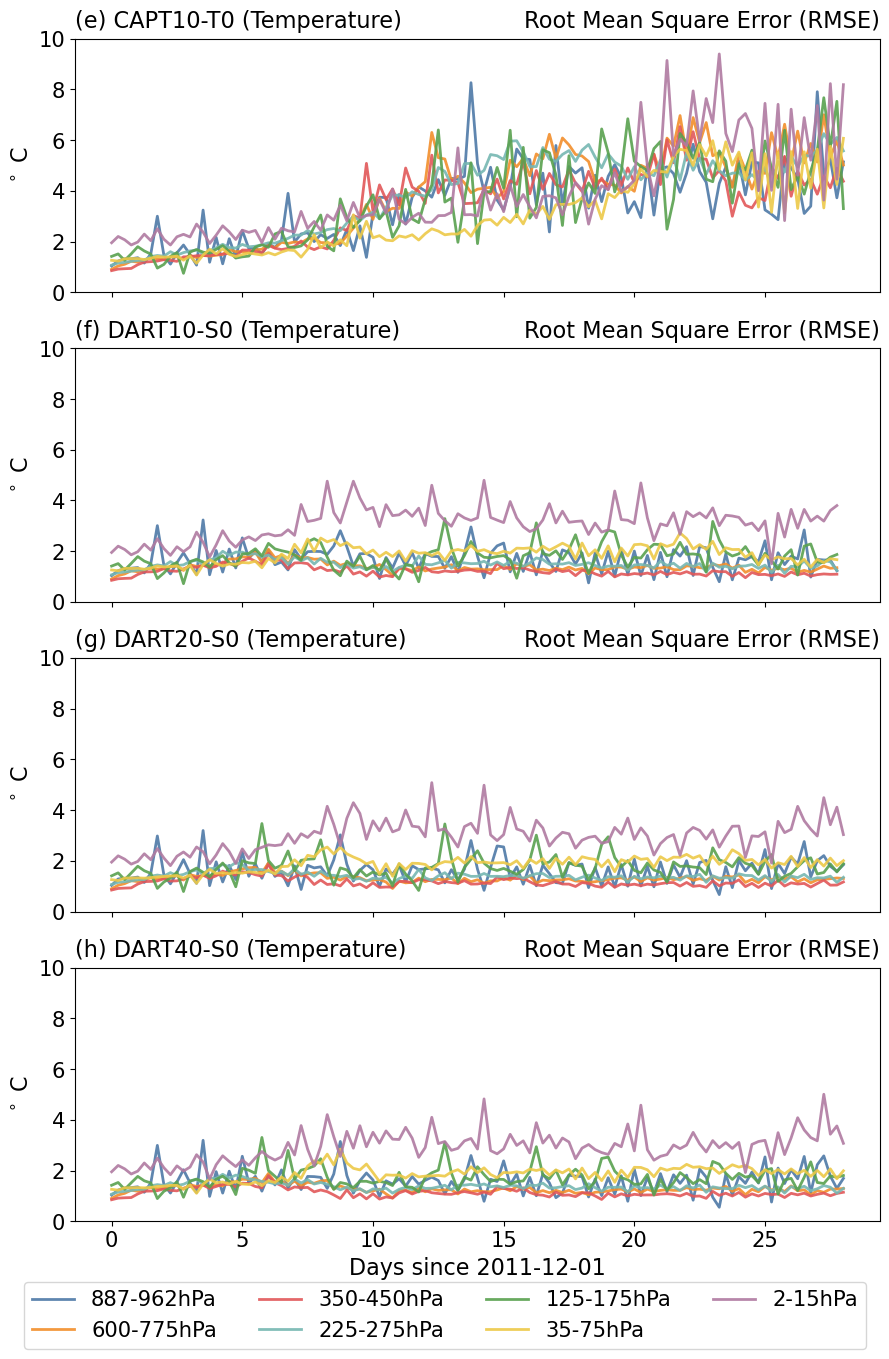

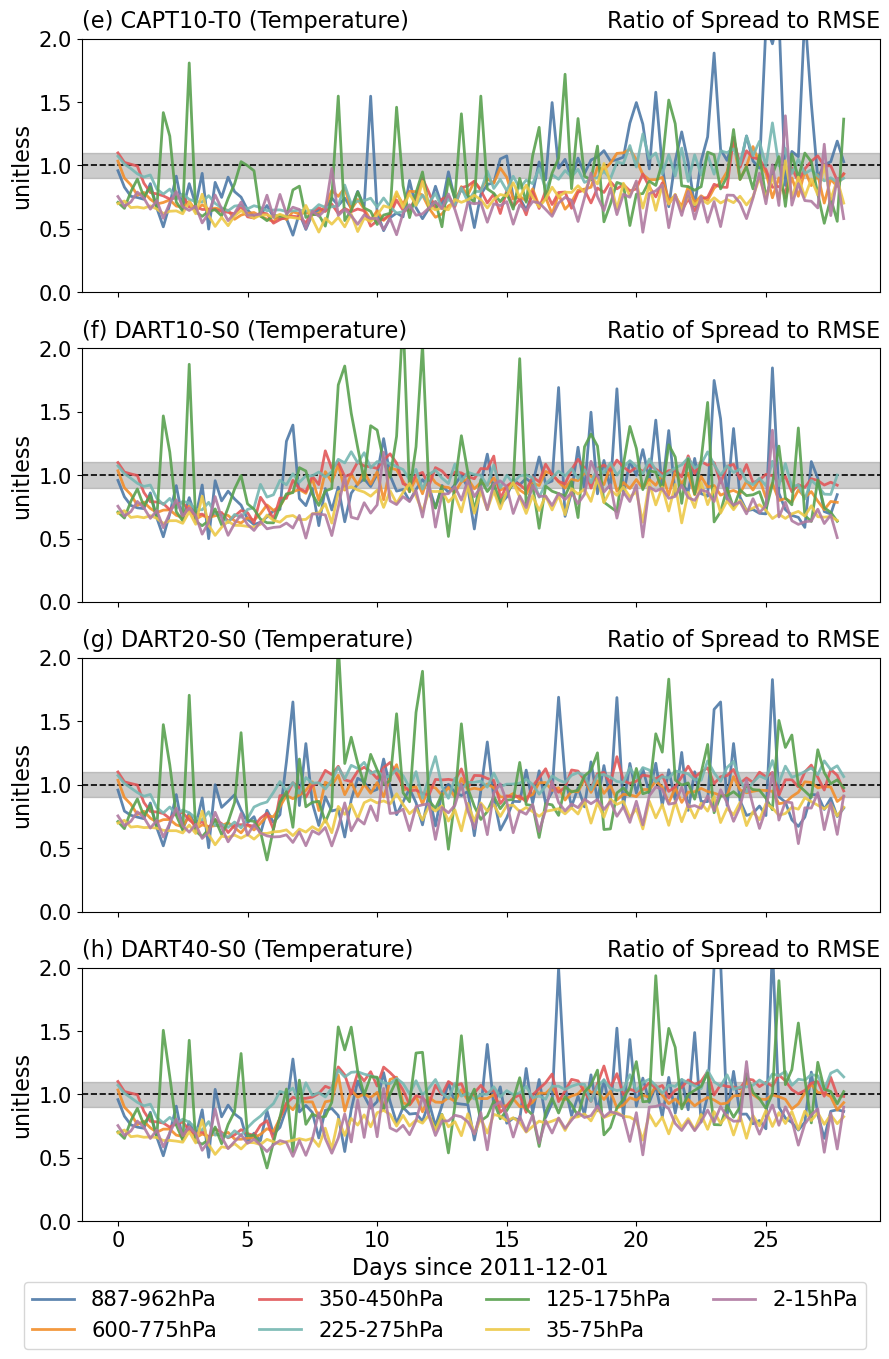

In [131]:
if __name__ == "__main__":
    top_path = "/compyfs/zhan391/v3_dart_cda_scratch"
    out_path = "/compyfs/zhan391/v3_dart_cda_scratch/diag_dart"
    fig_path = "./"
    
    # === Configuration and inputs ===
    exp_info = extract_exp_info()
    exp_cfg  = exp_info["global"]
    exps = ['CTRL10-S0','DART10-S0','DART20-S0','DART40-S0']  # , 'DARTEN40_INF0p6']
    labels = ['CAPT10-T0','DART10-S0','DART20-S0','DART40-S0']  # , 'DARTEN40_INF0p6']
    exp_dict = {
        label: exp_info["experiments"][exp_tgt]
        for exp_tgt,label in zip(exps,labels)
    }
    reg_dict = {
        "NH":      "Northern Hemisphere",
        "SH":      "Southern Hemisphere",
        "Tropics": "Tropics",
        "NA":      "North America",
        "Global":  "global",
    }

    varstr   = "Temperature"  # "U_WIND"
    varunt   = "$^\\circ$ C"  # "m s$^{-1}$"
    varlev   = "plevel"
    diag_set = "diag2"
    dtype    = "guess"            # also accepts 'VPguess', 'guess_RankHist' if supported
    tunit    = "2011-12-01"
    
    # Region name
    region   = "NH"
    regnam = reg_dict.get(region, region)

    # Only RMSE and Spread; we won't use rejection anymore
    metric_dict  = {
        "rmse": {
            "name": "Root Mean Square Error (RMSE)",
            "unit": varunt,
            "pad_frac": 0.05,
            "ylim": (0,10)
        },
        "spread": {
            "name": "Ratio of Spread to RMSE",
            "unit": "unitless",
            "pad_frac": 0.25,
            "ylim": (0,2),
            "reliability_band": (0.9, 1.1),   # <<< shaded band
        },
    }

    # Metrics to average across variables when building experiment means
    metrics = ["rmse", "spread"]
    
    # Only plot these levels; set to None to use all levels
    #plot_levs = ["887-962 hPa", "775-887 hPa", "450-600 hPa", "225-275 hPa", "75-125 hPa", "15-35 hPa"]
    plot_levs = None #[ "775-887 hPa", "450-600 hPa", "225-275 hPa", "75-125 hPa", "15-35 hPa"]
    plot_levs = None #[ "600-775 hPa", "450-600 hPa", "225-275 hPa", "75-125 hPa", "15-35 hPa"]

    vbound   = ([1, 7], [0, 18])  # (primary y-axis bounds, secondary y-axis bounds)
    xmin     = 0
    xmax     = 28
    xmean    = 15   # currently unused
    show     = True
    save     = True
    panel_width  = 9
    panel_height = 13
    fontz = 16
    dpi   = 600 
    
    # === Initialize diagnostics reader and discover available obs ===
    reader = DartObsDiagReader(exp_cfg)
    all_obs = reader.extract_obs_group()

    # Matches: non-satellite, level substring match, variable substring match (case-insensitive)
    matches = [
        (group, lev, vv)
        for group, levels in all_obs.items()
        if "Satellite" not in group
        for lev, variables in levels.items()
        if varlev.lower() in lev.lower()
        for vv in variables
        if varstr.lower() in vv.lower()
    ]

    if not matches:
        raise RuntimeError(
            f"No matches for var='{varstr}' at level like '{varlev}' "
            f"(excluding Satellite). Check your obs groups."
        )

    # === Gather data for each matching variable name ===
    data_dict = {}
    lev_dict  = {}
    for vgroup, vlev, vname in matches:
        print(f"Found match for variable {varstr} in {vgroup}: {vname}")
        # Build display/axis config for THIS variable name using the reader's helper
        var_cfg = reader.build_ts_var_dict(varstr, name=vname)
        # Extract metrics; pass exp_dict that is already defined
        dat, levs = reader.extract_metrics_data(
            var=varstr,
            var_dict=var_cfg[varstr],
            dtype=dtype,
            regnam=regnam,
            diag_set=diag_set,
            exp_dict=exp_dict,
        )
        data_dict[vname] = dat
        lev_dict[vname]  = levs

    # === Plotting ===
    plotter = ObsDiagPlotter(
        var=None, 
        var_dict=None, 
        data_dict=None, 
        plevstr=None,
        region=region,
        regnam=regnam, 
        fig_path=fig_path
    )
    
    # Ensure pressure levels consistent across matched variables
    lev_str = plotter.check_flat_lev_consistency(lev_dict)
    if not lev_str:
        raise RuntimeError("Pressure levels inconsistent across variables; cannot proceed.")
    
    # Drop 'rejection' from raw data if present, since we no longer use it
    for vname, vdata in data_dict.items():
        for exp_name, exp_data in vdata.items():
            exp_data.pop("rejection", None)

    # Calculate mean of all available observations (rmse, spread, and other consistent keys)
    data_dict_mean = plotter.compute_experiment_means(
        data_dict, diagnostic_keys
    )

    # Build a unified var_dict for the final plot (still reused from your original design)
    var_dict = plotter.build_ts_var_dict(
        varstr, name=varstr, y1axis=vbound[0], y2axis=vbound[1],
    )
    
    # Push state into plotter
    plotter.var = varstr
    plotter.var_dict = var_dict
    plotter.data_dict = data_dict_mean
    plotter.plevstr = lev_str

    # === Generate time series at selected levels: one figure per level, 2 panels (rmse & spread) ===
    if plot_levs is None:
        plot_levs = lev_str[1::2]

    for i, lev in enumerate(plot_levs):
        if lev not in lev_str:
            print(f"[WARN] Requested level '{lev}' not found in lev_str; skipping.")
            continue
            
    fig_idx = 1*len(exps)   # for panel lettering (a,b,c,...)

    plotter.plot_metric_by_experiment(
        plev_subset=plot_levs,
        metrics=metrics,
        metric_dict=metric_dict,
        xmin=xmin,
        xmax=xmax,
        xunit=tunit,
        fontz=fontz,
        dpi=dpi,
        panel_width=panel_width,
        panel_height=panel_height,
        show=show,
        save=save,
        fig_idx=fig_idx
    )